# Riyadh Internet Coverage — Exploratory Data Analysis
---
**Project:** Neighborhood DNA — The 15-Minute City Index  
**Layer:** Connectivity (Layer 4 of 4)  
**Objective:** Clean and explore internet coverage data across 189 Riyadh neighborhoods to build the connectivity layer for the Livability Score.  

**Pipeline:**
1. Load & Initial Profile
2. Feature Selection
3. Data Processing (types, nulls, duplicates)
4. Data Analysis (coverage distribution, connectivity tiers, neighborhood gaps)
5. Fix What Analysis Reveals (connectivity scoring)
6. Export (`Cleaned_Riyadh_Internet.csv`)

## 1 | Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# ── Dark Theme ──
plt.rcParams.update({
    'figure.facecolor': '#0a0e27',
    'axes.facecolor': '#0a0e27',
    'axes.edgecolor': '#2a2f4e',
    'axes.labelcolor': '#c4c7d4',
    'text.color': '#c4c7d4',
    'xtick.color': '#8b8fa3',
    'ytick.color': '#8b8fa3',
    'grid.color': '#1a1f3e',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 120,
    'figure.figsize': (14, 6)
})

GOLD   = '#f0c05a'
CYAN   = '#4fc3f7'
CORAL  = '#ff6b6b'
MINT   = '#66bb6a'
PURPLE = '#ab47bc'
PALETTE = [GOLD, CYAN, CORAL, MINT, PURPLE, '#ff8a65', '#42a5f5', '#ef5350']

pd.set_option('display.max_columns', None)
print('Setup complete.')

Setup complete.


In [2]:
url = 'https://raw.githubusercontent.com/AbdulrahmanB-25/Machine_Learning_Competition/main/DataSets/Internet.csv'
df_raw = pd.read_csv(url, encoding="utf-8-sig")

print(f"Loaded {len(df_raw):,} neighborhood records with {df_raw.shape[1]} columns.")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()

Loaded 189 neighborhood records with 4 columns.
Columns: ['Neighborhood', 'Fiber_Available', 'FWA_Available', 'Mobile_Available']


,Neighborhood,Fiber_Available,FWA_Available,Mobile_Available
0,Al Amal Dist.,0,1,1
1,Al Namudhajiyah Dist.,0,1,1
2,Al Jarradiyah Dist.,1,1,1
3,Al Sinaiyah Dist.,0,1,1
4,Manfuha Al Jadidah Dist.,0,1,1


## 2 | Initial Data Profile
First look at the raw dataset.

In [3]:
print("=" * 60)
print("DATA TYPES & MISSING VALUES")
print("=" * 60)
info_df = pd.DataFrame({
    'dtype':    df_raw.dtypes,
    'non_null': df_raw.count(),
    'null':     df_raw.isnull().sum(),
    'null_%':   (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(info_df)
print(f"\nTotal rows: {len(df_raw):,}")

DATA TYPES & MISSING VALUES
                   dtype  non_null  null  null_%
Neighborhood      object       189     0     0.0
Fiber_Available    int64       189     0     0.0
FWA_Available      int64       189     0     0.0
Mobile_Available   int64       189     0     0.0

Total rows: 189


In [4]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df_raw.describe(include="all")

DESCRIPTIVE STATISTICS


,Neighborhood,Fiber_Available,FWA_Available,Mobile_Available
count,189,189.000000,189.000000,189.0
unique,189,NaN,NaN,NaN
top,Al Amal Dist.,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,0.285714,0.925926,1.0
std,NaN,0.452954,0.262587,0.0
min,NaN,0.000000,0.000000,1.0
25%,NaN,0.000000,1.000000,1.0
50%,NaN,0.000000,1.000000,1.0
75%,NaN,1.000000,1.000000,1.0


## 3 | Feature Selection

This dataset is already lean — **4 columns**, all relevant. We keep everything:

| Feature | Role |
|---|---|
| `Neighborhood` | District identifier — join key for merging with other layers |
| `Fiber_Available` | Binary (0/1) — fiber optic internet availability |
| `FWA_Available` | Binary (0/1) — Fixed Wireless Access availability |
| `Mobile_Available` | Binary (0/1) — mobile network availability |

No columns dropped — dataset arrived pre-curated at the neighborhood level.

In [5]:
df = df_raw.copy()
print(f"All {len(df.columns)} features kept (dataset already lean).")
print(f"Shape: {df.shape}")

All 4 features kept (dataset already lean).
Shape: (189, 4)


## 4 | Data Processing
Validate types, check for nulls/duplicates, and ensure binary columns are clean.

In [6]:
initial_count = len(df)
cleaning_log = []

# Step 1: Check for null values
before = len(df)
df = df.dropna()
removed = before - len(df)
cleaning_log.append(('Null values', removed))
print(f"Step 1 — Null values removed: {removed:,}")

# Step 2: Check for duplicate neighborhoods
before = len(df)
df = df.drop_duplicates(subset=['Neighborhood'])
removed = before - len(df)
cleaning_log.append(('Duplicate neighborhoods', removed))
print(f"Step 2 — Duplicate neighborhoods removed: {removed:,}")

# Step 3: Validate binary columns are 0/1 only
binary_cols = ['Fiber_Available', 'FWA_Available', 'Mobile_Available']
before = len(df)
for col in binary_cols:
    df = df[df[col].isin([0, 1])]
removed = before - len(df)
cleaning_log.append(('Invalid binary values', removed))
print(f"Step 3 — Invalid binary values removed: {removed:,}")

df = df.reset_index(drop=True)

total_removed = initial_count - len(df)
print(f'\n{"=" * 60}')
print("CLEANING SUMMARY")
print(f'{"=" * 60}')
print(f"Started with:  {initial_count:,}")
print(f"Removed total: {total_removed:,} ({total_removed/initial_count*100:.2f}%)")
print(f"Final count:   {len(df):,}")

Step 1 — Null values removed: 0
Step 2 — Duplicate neighborhoods removed: 0
Step 3 — Invalid binary values removed: 0

CLEANING SUMMARY
Started with:  189
Removed total: 0 (0.00%)
Final count:   189


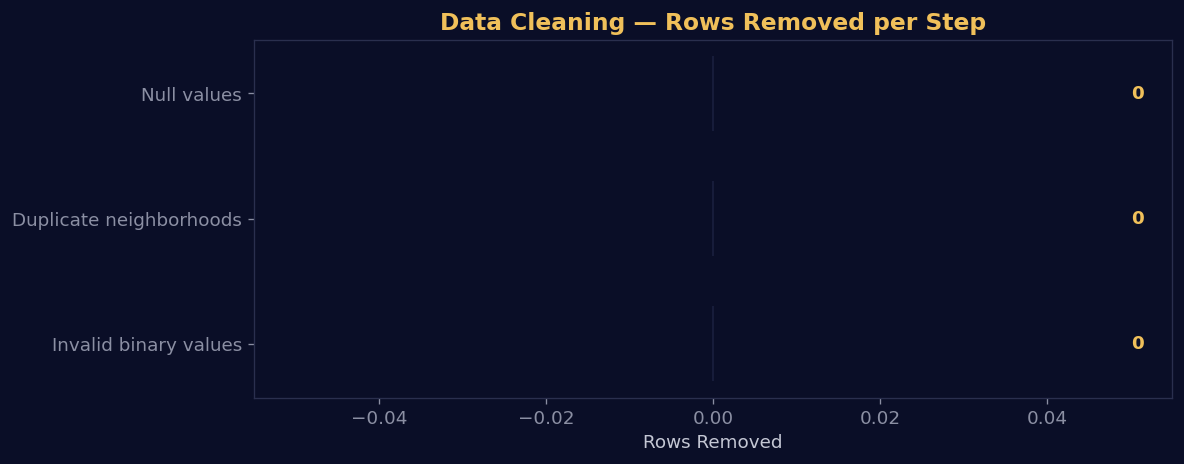

In [7]:
# ── Cleaning Summary Chart ──
fig, ax = plt.subplots(figsize=(10, 4))
steps  = [s[0] for s in cleaning_log]
counts = [s[1] for s in cleaning_log]
colors = [CORAL if c > 0 else "#2a2f4e" for c in counts]

bars = ax.barh(steps, counts, color=colors, edgecolor="#1a1f3e", height=0.6)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + max(max(counts), 1) * 0.05,
            bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=11, color=GOLD, fontweight='bold')

ax.set_xlabel('Rows Removed')
ax.set_title('Data Cleaning — Rows Removed per Step', fontsize=14, fontweight='bold', color=GOLD)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5 | Data Analysis
Explore coverage distribution, connectivity tiers, and identify underserved neighborhoods.

### 5.1 | Coverage by Technology

Coverage Summary:
  Fiber        54/189 neighborhoods (28.6%)
  FWA         175/189 neighborhoods (92.6%)
  Mobile      189/189 neighborhoods (100.0%)


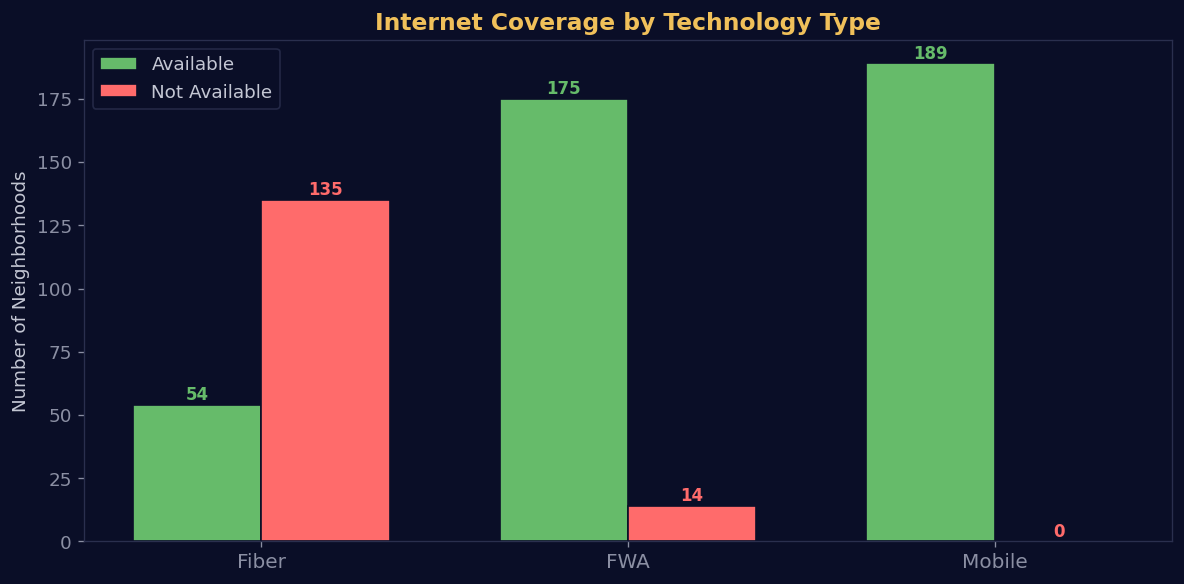

In [8]:
binary_cols = ['Fiber_Available', 'FWA_Available', 'Mobile_Available']
coverage = df[binary_cols].sum()
no_coverage = len(df) - coverage

print("Coverage Summary:")
for col in binary_cols:
    has = df[col].sum()
    pct = has / len(df) * 100
    tech = col.replace("_Available", "")
    print(f"  {tech:<10} {has:>4}/{len(df)} neighborhoods ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
labels = [c.replace("_Available", "") for c in binary_cols]
has_vals = [df[c].sum() for c in binary_cols]
no_vals  = [len(df) - v for v in has_vals]

x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, has_vals, w, color=MINT, edgecolor="#0a0e27", label="Available")
ax.bar(x + w/2, no_vals,  w, color=CORAL, edgecolor="#0a0e27", label="Not Available")

for i, (h, n) in enumerate(zip(has_vals, no_vals)):
    ax.text(i - w/2, h + 2, f'{h}', ha='center', fontsize=10, color=MINT, fontweight='bold')
    ax.text(i + w/2, n + 2, f'{n}', ha='center', fontsize=10, color=CORAL, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Number of Neighborhoods')
ax.set_title('Internet Coverage by Technology Type', fontsize=14, fontweight='bold', color=GOLD)
ax.legend(facecolor="#0a0e27", edgecolor="#2a2f4e")
plt.tight_layout()
plt.show()

### 5.2 | Connectivity Tiers
How many technologies does each neighborhood have access to?

Connectivity Tiers:
  Basic (1 tech)         14 neighborhoods (7.4%)
  Good (2 tech)         121 neighborhoods (64.0%)
  Full (3 tech)          54 neighborhoods (28.6%)


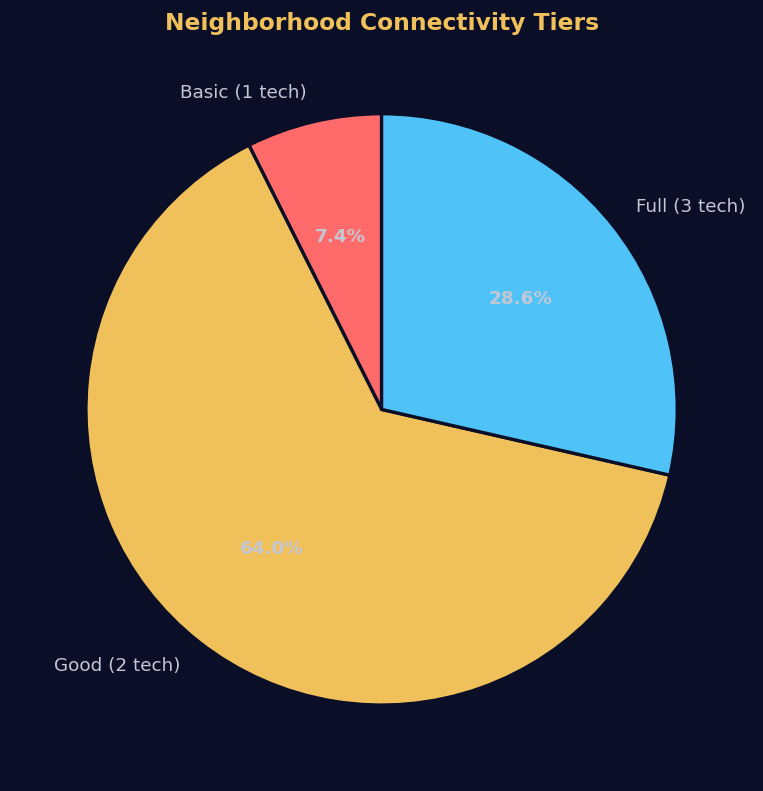

In [9]:
df['connectivity_score'] = df[binary_cols].sum(axis=1)

tier_counts = df['connectivity_score'].value_counts().sort_index()
tier_labels = {0: "No Coverage", 1: "Basic (1 tech)", 2: "Good (2 tech)", 3: "Full (3 tech)"}

print("Connectivity Tiers:")
for score, count in tier_counts.items():
    label = tier_labels.get(score, f"Score {score}")
    pct = count / len(df) * 100
    print(f"  {label:<20} {count:>4} neighborhoods ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 8))
colors_pie = [CORAL, GOLD, CYAN, MINT]
labels_pie = [tier_labels.get(s, str(s)) for s in tier_counts.index]

wedges, texts, autotexts = ax.pie(
    tier_counts.values, labels=labels_pie,
    colors=colors_pie[:len(tier_counts)], autopct='%1.1f%%',
    textprops={'color': '#c4c7d4', 'fontsize': 11},
    wedgeprops={'edgecolor': '#0a0e27', 'linewidth': 2},
    startangle=90
)
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('Neighborhood Connectivity Tiers', fontsize=14, fontweight='bold', color=GOLD)
plt.show()

### 5.3 | Fiber Coverage Gap
Fiber is the biggest differentiator — which neighborhoods have it?

In [10]:
fiber_yes = df[df['Fiber_Available'] == 1]
fiber_no  = df[df['Fiber_Available'] == 0]

print(f"Neighborhoods WITH fiber:    {len(fiber_yes):>4} ({len(fiber_yes)/len(df)*100:.1f}%)")
print(f"Neighborhoods WITHOUT fiber: {len(fiber_no):>4} ({len(fiber_no)/len(df)*100:.1f}%)")
print(f"\nFiber-connected neighborhoods (sample):")
for name in fiber_yes['Neighborhood'].head(10).values:
    print(f"  ✓ {name}")

print(f"\nNo fiber (sample):")
for name in fiber_no['Neighborhood'].head(10).values:
    print(f"  ✗ {name}")

Neighborhoods WITH fiber:      54 (28.6%)
Neighborhoods WITHOUT fiber:  135 (71.4%)

Fiber-connected neighborhoods (sample):
  ✓ Al Jarradiyah Dist.
  ✓ West Umm Al Hamam Dist.
  ✓ King Fahd Dist.
  ✓ Al Nada Dist.
  ✓ Al Woroud Dist.
  ✓ King Faisal Dist.
  ✓ Al Aziziyah Dist.
  ✓ Al Mansurah Dist.
  ✓ Al Saadah Dist.
  ✓ Al Wizarat Dist.

No fiber (sample):
  ✗ Al Amal Dist.
  ✗ Al Namudhajiyah Dist.
  ✗ Al Sinaiyah Dist.
  ✗ Manfuha Al Jadidah Dist.
  ✗ Al Fakhiriyah Dist.
  ✗ Al Dirah Dist.
  ✗ East Umm Al Hamam Dist.
  ✗ Al Sharafiyah Dist.
  ✗ Al Hada Dist.
  ✗ North Mathar Dist.


### 5.4 | Coverage Correlation
Do technologies tend to appear together?

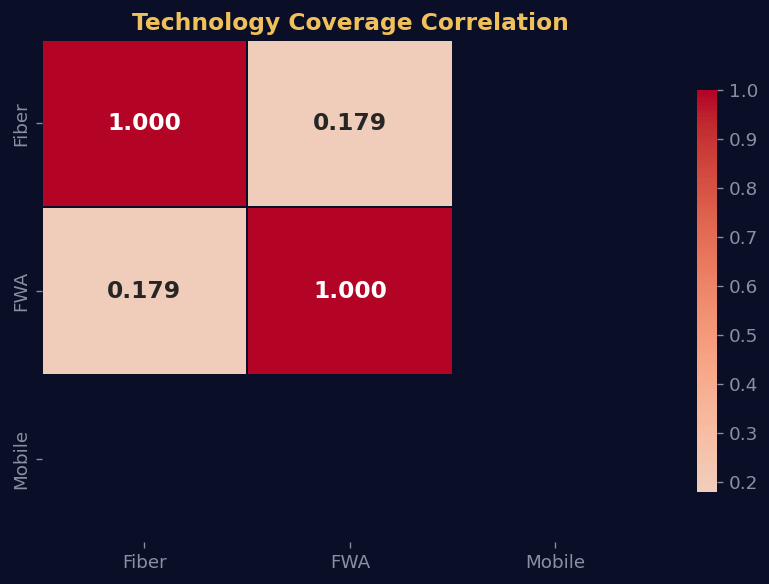

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[binary_cols].corr()

sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
    linewidths=1, linecolor='#0a0e27',
    cbar_kws={'shrink': 0.8},
    annot_kws={'fontsize': 14, 'fontweight': 'bold'},
    xticklabels=[c.replace("_Available", "") for c in binary_cols],
    yticklabels=[c.replace("_Available", "") for c in binary_cols],
    ax=ax
)
ax.set_title('Technology Coverage Correlation', fontsize=14, fontweight='bold', color=GOLD)
plt.tight_layout()
plt.show()

## 6 | Fix What Analysis Reveals
The analysis reveals that Mobile coverage is universal (100%) — it adds no discriminating power. The real differentiator is Fiber access, which only covers ~29% of neighborhoods. We add a `connectivity_score` column (0–3) to quantify each neighborhood's coverage level for the final model.

### 6.1 | Final Clean Dataset Profile

In [12]:
print("=" * 60)
print("FINAL CLEAN DATASET PROFILE")
print("=" * 60)
print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn Details:")
for col in df.columns:
    print(f"  {col:<25} {str(df[col].dtype):<10} | nulls: {df[col].isnull().sum()} | unique: {df[col].nunique():,}")
print(f"\nDescriptive Stats:")
df.describe(include="all")

FINAL CLEAN DATASET PROFILE
Rows:    189
Columns: 5

Column Details:
  Neighborhood              object     | nulls: 0 | unique: 189
  Fiber_Available           int64      | nulls: 0 | unique: 2
  FWA_Available             int64      | nulls: 0 | unique: 2
  Mobile_Available          int64      | nulls: 0 | unique: 1
  connectivity_score        int64      | nulls: 0 | unique: 3

Descriptive Stats:


,Neighborhood,Fiber_Available,FWA_Available,Mobile_Available,connectivity_score
count,189,189.000000,189.000000,189.0,189.000000
unique,189,NaN,NaN,NaN,NaN
top,Al Amal Dist.,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,0.285714,0.925926,1.0,2.211640
std,NaN,0.452954,0.262587,0.0,0.562736
min,NaN,0.000000,0.000000,1.0,1.000000
25%,NaN,0.000000,1.000000,1.0,2.000000
50%,NaN,0.000000,1.000000,1.0,2.000000
75%,NaN,1.000000,1.000000,1.0,3.000000


## 7 | Export Clean Dataset
Final internet coverage dataset with connectivity scoring.

In [13]:
output_file = 'Cleaned_Riyadh_Internet.csv'
df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Exported: '{output_file}'")
print(f"   Neighborhoods: {len(df)}")
print(f"   Columns:       {list(df.columns)}")
print(f"   Size:          {os.path.getsize(output_file) / 1024:.1f} KB")

try:
    from google.colab import files
    files.download(output_file)
except ImportError:
    print("   (Not in Colab — file saved locally)")

Exported: 'Cleaned_Riyadh_Internet.csv'
   Neighborhoods: 189
   Columns:       ['Neighborhood', 'Fiber_Available', 'FWA_Available', 'Mobile_Available', 'connectivity_score']
   Size:          4.6 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8 | Key Findings & Next Steps

### What We Learned:
1. **Mobile is Universal**: 100% of neighborhoods have mobile coverage — it's not a differentiator for livability.
2. **FWA is Near-Universal**: 93% coverage across neighborhoods — strong baseline connectivity.
3. **Fiber is the Gap**: Only 29% of neighborhoods have fiber — this is the key connectivity differentiator for the livability model.
4. **Connectivity Tiers**: Neighborhoods split into 3 practical tiers: Full (Fiber+FWA+Mobile at 29%), Good (FWA+Mobile at 64%), and Basic (Mobile-only at 7%).

### Next Steps:
- Merge `connectivity_score` with the neighborhood profiles from other layers.
- Use Fiber availability as a premium signal in the Livability Score weighting.
- Build the composite Livability Score from all 4 layers.